<a href="https://colab.research.google.com/github/naveed82/my-data-project/blob/main/Project_First_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [197]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [198]:
import pandas as pd

file_path = "/content/drive/MyDrive/wbcd_breast_cancer_data.csv"

df = pd.read_csv(file_path)

print(df.head())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [199]:
# Check missing values in the data
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [200]:
# dropping unamed column
df = df.drop(columns=['Unnamed: 32'], errors='ignore')

In [204]:
# verifying the data
df = df.dropna()
print(df['diagnosis'].unique())

['M' 'B']


In [205]:
df['diagnosis'] = df['diagnosis'].astype(str).str[0]
print(df['diagnosis'].unique())

['M' 'B']


In [206]:
# Converting  target data into number
df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})

# Droping  unnecessary columns in the data
X = df.drop(columns=['id', 'Unnamed: 32', 'diagnosis'], errors='ignore')
y = df['diagnosis']

print(X.shape)
print(y.value_counts())

(569, 30)
diagnosis
1    357
0    212
Name: count, dtype: int64


In [207]:
# Separating input features  and target variable
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Verifying shapes and class distribution in the data
print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (569, 31)
Target distribution:
 diagnosis
1    357
0    212
Name: count, dtype: int64


In [208]:
# Removing NA values
df = df[df['diagnosis'].notna()]

# Re-definig  X and y
X = df.drop(columns=['diagnosis', 'id', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

# verify if NA exists in the data to keep data clean
print(y.isnull().sum())

0


In [209]:
X = X.dropna()
y = y.loc[X.index]  # make sure y aligns

In [210]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaNs in X?", X.isnull().sum().sum())
print("Any NaNs in y?", y.isnull().sum())

X shape: (569, 30)
y shape: (569,)
Any NaNs in X? 0
Any NaNs in y? 0


In [211]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dat into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verifying
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)


In [212]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize all 4 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    # Use scaled data for LR and KNN
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

# Verifying the results

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.982456   0.986111  0.986111  0.986111
1        Decision Tree  0.912281   0.955882  0.902778  0.928571
2          Naive Bayes  0.938596   0.945205  0.958333  0.951724
3                  KNN  0.956140   0.958904  0.972222  0.965517


In [214]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Selecting  top 10 features
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

#Verifying names  of selected features
selected_features = X.columns[selector.get_support()]
print("Top 10 features:", list(selected_features))

# Reducing the data to check robuteness
X_reduced = X[selected_features]

# Spliting the data
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling  for LR and KNN models
scaler = StandardScaler()
X_train_red_scaled = scaler.fit_transform(X_train_red)
X_test_red_scaled = scaler.transform(X_test_red)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Training  & evaluating
results_reduced = []

for name, model in models.items():
    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_red_scaled, y_train_red)
        y_pred = model.predict(X_test_red_scaled)
    else:
        model.fit(X_train_red, y_train_red)
        y_pred = model.predict(X_test_red)

    acc = accuracy_score(y_test_red, y_pred)
    prec = precision_score(y_test_red, y_pred)
    rec = recall_score(y_test_red, y_pred)
    f1 = f1_score(y_test_red, y_pred)

    results_reduced.append([name, acc, prec, rec, f1])

# showung the results
results_reduced_df = pd.DataFrame(results_reduced, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
print(results_reduced_df)

Top 10 features: ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concavity_worst', 'concave points_worst']
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.947368   0.971429  0.944444  0.957746
1        Decision Tree  0.921053   0.943662  0.930556  0.937063
2          Naive Bayes  0.929825   0.944444  0.944444  0.944444
3                  KNN  0.956140   0.958904  0.972222  0.965517


In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

# Getting F-scores of all features
feature_scores = selector.scores_[selector.get_support()]

# Create=ing  a DataFrame for plotting
feat_df = pd.DataFrame({
    'Feature': selected_features,
    'F_score': feature_scores
}).sort_values(by='F_score', ascending=True)

/tmp/ipykernel_153/3787395780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F_score', y='Feature', data=feat_df, palette='viridis')


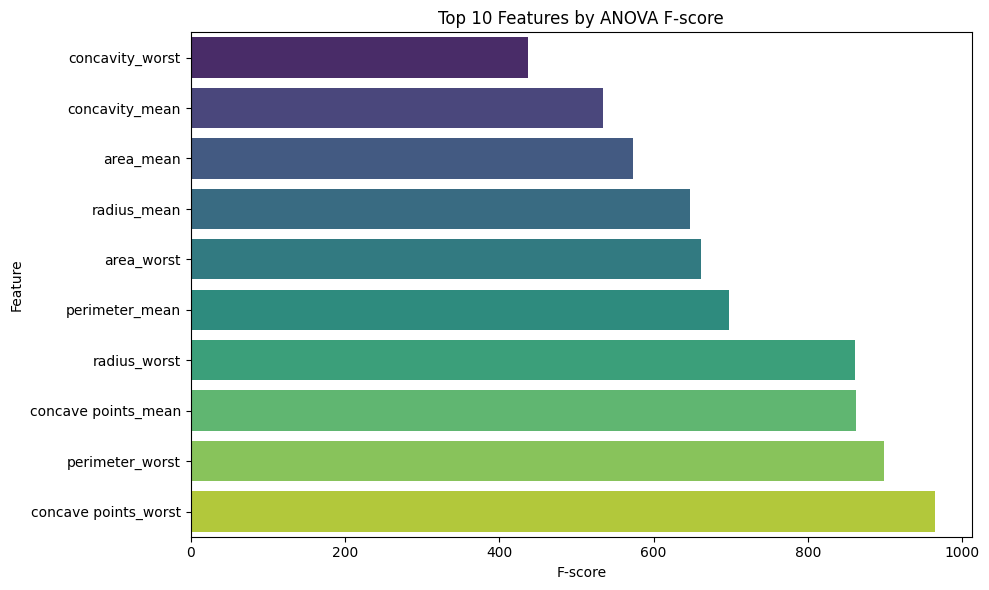

In [216]:
plt.figure(figsize=(10,6))
sns.barplot(x='F_score', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 10 Features by ANOVA F-score')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [228]:
X['tumor_size_group'] = pd.cut(
    X['radius_mean'],
    bins=[0, 12, 17, X['radius_mean'].max()],
    labels=['Small', 'Medium', 'Large']
)

# Checking counts
print(X['tumor_size_group'].value_counts())

tumor_size_group
Medium    280
Small     171
Large     118
Name: count, dtype: int64


In [230]:

# Objective 3: Evaluatng  Model Performance by Tumor Size Groups


import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



# Removing any non-numeric columns
X_numeric = X.select_dtypes(include=['float64', 'int64'])


#  Selecting Top 10 Features

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X_numeric, y)
top_features = X_numeric.columns[selector.get_support()]
print("Top 10 features:", list(top_features))


# Step 2: Creating Tumor Size Groups based on radius_mean

X['tumor_size_group'] = pd.cut(
    X['radius_mean'],
    bins=[0, 12, 17, X['radius_mean'].max()],
    labels=['Small', 'Medium', 'Large']
)
print("Tumor size group counts:\n", X['tumor_size_group'].value_counts())


# Step 3: Defining Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


# Step 4: Evaluating Models Per Tumor Group

group_results = []

for group in X['tumor_size_group'].unique():
    idx = X['tumor_size_group'] == group
    X_group = X.loc[idx, top_features]
    y_group = y.loc[idx]

    # Removing groups with fewer than 4 samples to avoid splitting errors
    if len(X_group) < 4:
        print(f"Skipping group '{group}' due to too few samples")
        continue

    # Spliting group into train/test to avoid errors)
    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X_group, y_group, test_size=0.2, random_state=42
    )

    # Scaling features for LR and KNN
    scaler = StandardScaler()
    X_train_g_scaled = scaler.fit_transform(X_train_g)
    X_test_g_scaled = scaler.transform(X_test_g)

    # Again Train and evaluate each model
    for name, model in models.items():
        if name in ["Logistic Regression", "KNN"]:
            model.fit(X_train_g_scaled, y_train_g)
            y_pred_g = model.predict(X_test_g_scaled)
        else:
            model.fit(X_train_g, y_train_g)
            y_pred_g = model.predict(X_test_g)

        acc = accuracy_score(y_test_g, y_pred_g)
        prec = precision_score(y_test_g, y_pred_g, zero_division=0)
        rec = recall_score(y_test_g, y_pred_g, zero_division=0)
        f1 = f1_score(y_test_g, y_pred_g, zero_division=0)

        group_results.append([group, name, acc, prec, rec, f1])


#  Converting to DataFrame

group_results_df = pd.DataFrame(
    group_results,
    columns=["Tumor Size", "Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

print(group_results_df)

Top 10 features: ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'concavity_worst', 'concave points_worst']
Tumor size group counts:
 tumor_size_group
Medium    280
Small     171
Large     118
Name: count, dtype: int64
   Tumor Size                Model  Accuracy  Precision    Recall  F1-score
0       Large  Logistic Regression  1.000000   0.000000  0.000000  0.000000
1       Large        Decision Tree  0.958333   0.000000  0.000000  0.000000
2       Large          Naive Bayes  1.000000   0.000000  0.000000  0.000000
3       Large                  KNN  1.000000   0.000000  0.000000  0.000000
4       Small  Logistic Regression  1.000000   1.000000  1.000000  1.000000
5       Small        Decision Tree  0.971429   1.000000  0.971429  0.985507
6       Small          Naive Bayes  0.971429   1.000000  0.971429  0.985507
7       Small                  KNN  1.000000   1.000000  1.000000  1.000000
8      M

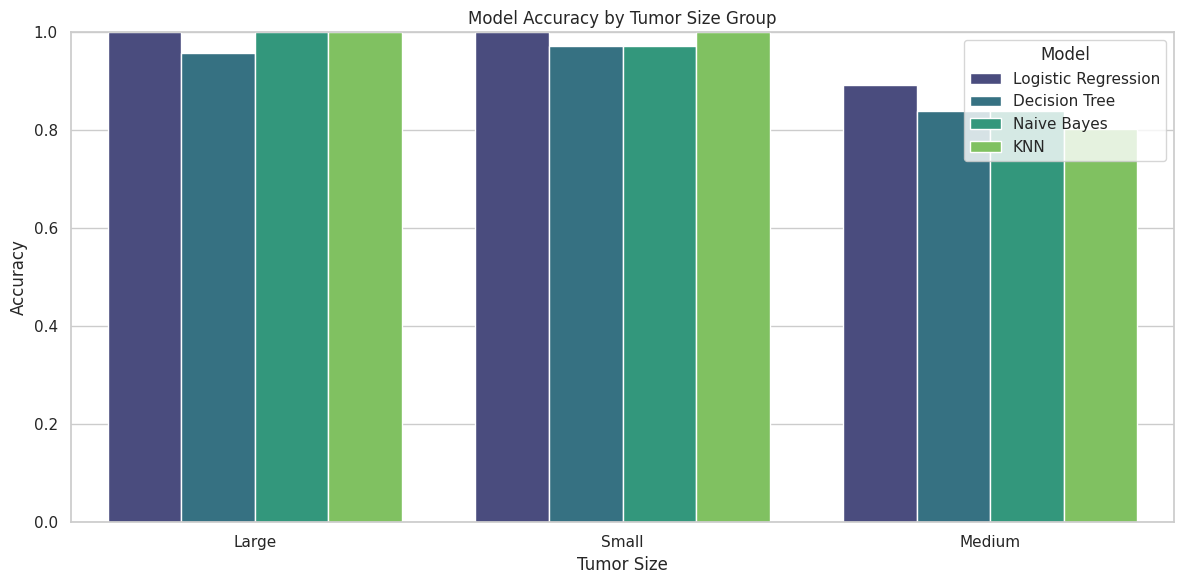

In [231]:
# Seting plot style
sns.set(style="whitegrid")

plt.figure(figsize=(12,6))
sns.barplot(
    x='Tumor Size',
    y='Accuracy',
    hue='Model',
    data=group_results_df,
    palette='viridis'
)
plt.title('Model Accuracy by Tumor Size Group')
plt.ylabel('Accuracy')
plt.xlabel('Tumor Size')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.tight_layout()
plt.show()